## ***FAISS LSH***

### ***Install & Imports***

In [1]:
!pip install faiss-cpu azure-storage-blob -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 60.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 11.7 MB/s eta 0:00:00


In [2]:
import json
import os
from pathlib import Path
from kaggle_secrets import UserSecretsClient
import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

### ***Config***  

In [3]:
secrets = UserSecretsClient()
os.environ["AZURE_STORAGE_CONN_STR"] = secrets.get_secret("AZURE_STORAGE_CONN_STR")
os.environ["AZURE_CONTAINER"] = secrets.get_secret("AZURE_CONTAINER")

In [4]:
OUTPUT_DIR = Path("/kaggle/working/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("FAISS:", faiss.__version__)

FAISS: 1.13.2


### ***Azure Blob Helpers***

In [5]:
def load_from_azure(filename: str):
    from azure.storage.blob import BlobServiceClient
    conn_str  = os.environ["AZURE_STORAGE_CONN_STR"]
    container = BlobServiceClient.from_connection_string(conn_str).get_container_client(os.environ["AZURE_CONTAINER"])
    return json.loads(container.download_blob(f"notebook_data/{filename}").readall())

In [6]:
def save_to_azure(data, filename: str):
    from azure.storage.blob import BlobServiceClient
    conn_str  = os.environ["AZURE_STORAGE_CONN_STR"]
    container = BlobServiceClient.from_connection_string(conn_str).get_container_client(os.environ["AZURE_CONTAINER"])
    container.upload_blob(name=f"notebook_data/{filename}", data=json.dumps(data), overwrite=True)
    print(f"[Azure] Saved → notebook_data/{filename}")

In [7]:
print("Loading data from Azure Blob...")
raw_stream = load_from_azure("raw_stream.json")
mr_stats   = load_from_azure("mr_symbol_stats.json")
print(f"raw_stream: {len(raw_stream):,} records")
print(f"mr_symbol_stats: {len(mr_stats)} symbols")

Loading data from Azure Blob...
raw_stream: 32,250 records
mr_symbol_stats: 20 symbols


### ***Per-Symbol Feature Matrix***

In [8]:
df_raw = pd.DataFrame(raw_stream)

def build_symbol_features(df: pd.DataFrame) -> pd.DataFrame:
    """One feature vector per symbol describing its market behaviour."""
    rows = []
    for sym, grp in df.groupby("symbol"):
        grp     = grp.sort_values("open_time").reset_index(drop=True)
        closes  = grp["close"].astype(float)
        volumes = grp["volume"].astype(float)
        highs   = grp["high"].astype(float)
        lows    = grp["low"].astype(float)
        pct_chg = closes.pct_change().dropna()

        rows.append({
            "symbol":          sym,
            "mean_close":      closes.mean(),
            "std_close":       closes.std(),
            "price_range_pct": (closes.max() - closes.min()) / closes.min() * 100 if closes.min() > 0 else 0,
            "volatility":      pct_chg.std(),
            "trend_slope":     float(np.polyfit(range(len(closes)), closes / closes.mean(), 1)[0]),
            "pct_candles_up":  (pct_chg > 0).mean() * 100,
            "skewness":        float(pct_chg.skew()),
            "kurtosis":        float(pct_chg.kurt()),
            "mean_volume":     volumes.mean(),
            "volume_cv":       volumes.std() / volumes.mean() if volumes.mean() > 0 else 0,
            "avg_body_pct":    (abs(closes - grp["open"].astype(float)) / grp["open"].astype(float) * 100).mean(),
            "avg_range_pct":   ((highs - lows) / grp["open"].astype(float) * 100).mean(),
        })
    return pd.DataFrame(rows).set_index("symbol")

In [9]:
df_sym = build_symbol_features(df_raw)
print(f"Feature matrix: {df_sym.shape} ({df_sym.shape[0]} coins × {df_sym.shape[1]} features)")
print(df_sym.head())


Feature matrix: (20, 12) (20 coins × 12 features)
         mean_close  std_close  price_range_pct  volatility  trend_slope  \
symbol                                                                     
AAVEUSD  119.180136   2.334457        10.658587    0.003250     0.000022   
ADAUSD     0.285083   0.015578        22.019136    0.003759     0.000104   
ALGOUSD    0.089211   0.003319        14.280554    0.002788     0.000065   
ATOMUSD    2.033332   0.051931        10.076915    0.003199    -0.000035   
AVAXUSD    9.212232   0.474462        19.296117    0.003509     0.000093   

         pct_candles_up  skewness   kurtosis    mean_volume  volume_cv  \
symbol                                                                   
AAVEUSD       28.411911  0.858024  20.986099     142.982436   1.721344   
ADAUSD        44.975186  0.592538  26.568042  720746.289549   1.464400   
ALGOUSD       29.360646  0.290437  15.338830  120867.612055   1.368721   
ATOMUSD       37.468983 -0.481671  20.009113  

### ***Normalise & Build FAISS LSH Index***  

In [10]:
df_clean = df_sym.fillna(0).replace([np.inf, -np.inf], 0)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_clean).astype(np.float32)
symbols = df_clean.index.tolist()

In [11]:
d = X_scaled.shape[1]
n_bits = d * 8
index = faiss.IndexLSH(d, n_bits)
index.add(X_scaled)
print(f"FAISS LSH index built | {index.ntotal} vectors | {d} dims | {n_bits} hash bits")

FAISS LSH index built | 20 vectors | 12 dims | 96 hash bits


### ***Find Similar Pairs***  

In [12]:
TOP_K        = 6
MAX_DISTANCE = 3.0

distances, indices = index.search(X_scaled, TOP_K)

In [13]:
pairs = []
seen  = set()
for i, (dists, idxs) in enumerate(zip(distances, indices)):
    for dist, j in zip(dists, idxs):
        if j < 0 or j == i:
            continue
        key = tuple(sorted([symbols[i], symbols[j]]))
        if key in seen:
            continue
        seen.add(key)
        pairs.append({
            "symbol_a":  symbols[i],
            "symbol_b":  symbols[j],
            "distance":  round(float(dist), 4),
            "similarity": round(1.0 / (1.0 + float(dist)), 4),
        })

In [14]:
pairs_df = pd.DataFrame(pairs).sort_values("distance").reset_index(drop=True)
print(f"Found {len(pairs_df)} similar pairs")
print("\nTop 15 most similar pairs:")
print(pairs_df.head(15).to_string(index=False))

Found 67 similar pairs

Top 15 most similar pairs:
symbol_a symbol_b  distance  similarity
  ICPUSD  NEARUSD       4.0      0.2000
  ADAUSD   XLMUSD       6.0      0.1429
 AVAXUSD  LINKUSD       7.0      0.1250
  XLMUSD   XRPUSD       7.0      0.1250
  ETHUSD   LTCUSD       8.0      0.1111
  ETHUSD  LINKUSD       8.0      0.1111
  ADAUSD   LTCUSD       8.0      0.1111
 AVAXUSD   FILUSD       8.0      0.1111
  ETCUSD   FILUSD       9.0      0.1000
 AVAXUSD   ETCUSD       9.0      0.1000
 ALGOUSD  NEARUSD       9.0      0.1000
  FILUSD   UNIUSD       9.0      0.1000
  ADAUSD   XRPUSD       9.0      0.1000
 NEARUSD   UNIUSD      10.0      0.0909
  ETCUSD  NEARUSD      10.0      0.0909


### ***Cluster Coins***  

In [15]:
clusters  = {}
assigned  = {}
cluster_id = 0

In [16]:
for i, sym in enumerate(symbols):
    if sym in assigned:
        continue
    dists, idxs = index.search(X_scaled[i:i+1], len(symbols))
    members = [symbols[j] for d, j in zip(dists[0], idxs[0])
               if j >= 0 and d < MAX_DISTANCE and symbols[j] not in assigned]
    if members:
        for m in members:
            assigned[m] = cluster_id
        clusters[cluster_id] = members
        cluster_id += 1

In [30]:
for sym in symbols:
    if sym not in assigned:
        assigned[sym] = cluster_id
        clusters[cluster_id] = [sym]
        cluster_id += 1

multi = {cid: members for cid, members in clusters.items() if len(members) > 1}
solo  = {cid: members for cid, members in clusters.items() if len(members) == 1}

print(f"\n{len(clusters)} clusters identified: {len(multi)} multi-coin, {len(solo)} single-coin")
for cid, members in sorted(multi.items(), key=lambda x: -len(x[1])):
    print(f"Cluster {cid}: {members}")


20 clusters identified: 0 multi-coin, 20 single-coin


### ***Recommendations***

In [18]:
def get_similar_coins(symbol: str, top_n: int = 5) -> list:
    if symbol not in symbols:
        print(f"[WARN] {symbol} not in index. Available: {symbols}")
        return []
    idx = symbols.index(symbol)
    dists, idxs = index.search(X_scaled[idx:idx+1], top_n + 1)
    return [
        {"symbol": symbols[j], "distance": round(float(d), 4), "similarity": round(1.0 / (1.0 + float(d)), 4)}
        for d, j in zip(dists[0], idxs[0]) if j >= 0 and j != idx
    ][:top_n]

In [23]:
print("Recommendations: ")
for sym in symbols[:3]:
    similar = get_similar_coins(sym)
    print(f"\n  Similar to {sym}:")
    for s in similar:
        print(f"{s['symbol']:12s}  similarity={s['similarity']:.3f}")

Recommendations: 

  Similar to AAVEUSD:
AVAXUSD       similarity=0.083
ALGOUSD       similarity=0.071
ADAUSD        similarity=0.067
ETCUSD        similarity=0.067
LTCUSD        similarity=0.067

  Similar to ADAUSD:
XLMUSD        similarity=0.143
LTCUSD        similarity=0.111
XRPUSD        similarity=0.100
ALGOUSD       similarity=0.071
FILUSD        similarity=0.071

  Similar to ALGOUSD:
NEARUSD       similarity=0.100
ETCUSD        similarity=0.083
ICPUSD        similarity=0.083
XLMUSD        similarity=0.083
AAVEUSD       similarity=0.071


### ***Visualizations***  

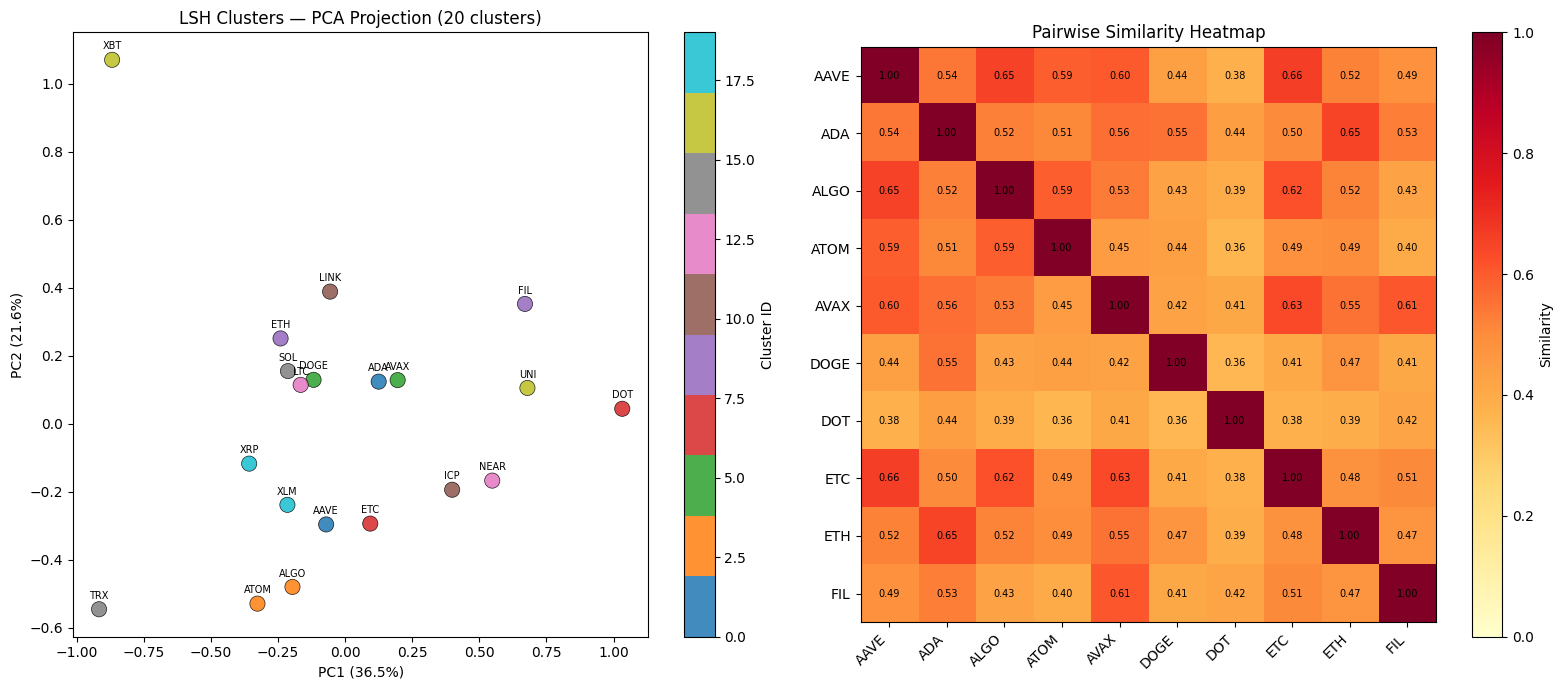

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PCA scatter coloured by cluster
pca         = PCA(n_components=2)
X_2d        = pca.fit_transform(X_scaled)
cluster_ids = [assigned.get(s, -1) for s in symbols]

ax = axes[0]
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_ids, cmap="tab10",
                     s=120, alpha=0.85, edgecolors="k", linewidths=0.5)
for i, sym in enumerate(symbols):
    ax.annotate(sym.replace("USD",""), (X_2d[i,0], X_2d[i,1]),
                fontsize=7, ha="center", va="bottom", xytext=(0,6), textcoords="offset points")
ax.set_title(f"LSH Clusters — PCA Projection ({len(clusters)} clusters)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(scatter, ax=ax, label="Cluster ID")

# Similarity heatmap
n     = min(10, len(symbols))
syms  = symbols[:n]
X_sub = X_scaled[:n]
sim   = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim[i, j] = 1.0 / (1.0 + float(np.linalg.norm(X_sub[i] - X_sub[j])))

ax2 = axes[1]
im  = ax2.imshow(sim, cmap="YlOrRd", vmin=0, vmax=1)
short = [s.replace("USD","") for s in syms]
ax2.set_xticks(range(n)); ax2.set_yticks(range(n))
ax2.set_xticklabels(short, rotation=45, ha="right")
ax2.set_yticklabels(short)
for i in range(n):
    for j in range(n):
        ax2.text(j, i, f"{sim[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax2.set_title("Pairwise Similarity Heatmap")
plt.colorbar(im, ax=ax2, label="Similarity")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lsh_visualisation.png", dpi=150, bbox_inches="tight")
plt.show()

### ***Save Outputs to Azure***

In [28]:
pairs_list     = pairs_df.to_dict(orient="records")
cluster_output = {str(k): v for k, v in clusters.items()}

save_to_azure(pairs_list, "lsh_similar_pairs.json")
save_to_azure(cluster_output, "lsh_coin_clusters.json")

pairs_df.to_csv(OUTPUT_DIR / "lsh_similar_pairs.csv", index=False)
with open(OUTPUT_DIR / "lsh_coin_clusters.json", "w") as f:
    json.dump(cluster_output, f, indent=2)

[Azure] Saved → notebook_data/lsh_similar_pairs.json
[Azure] Saved → notebook_data/lsh_coin_clusters.json
